# Análisis Exploratorio de Datos (EDA) - Dataset REHAB
Este notebook realiza el análisis exploratorio y la verificación del dataset **REHAB** (Rehab_exercise), el cual consta de 16 movimientos de rehabilitación de pacientes post-ACV.

A continuación se resuelven cada uno de los puntos solicitados paso a paso de manera sencilla y estructurada.


In [1]:
# 1. Setup y Carga de Librerías
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Definir la ruta del directorio de datos
DATA_DIR = "../data"
print("Librerías cargadas correctamente.")


Librerías cargadas correctamente.


## Paso 1: Verificación de correspondencia entre Sensor 1 y Sensor 2
Para corroborar si las lecturas del **Sensor 1 (IMU)** corresponden a las del **Sensor 2 (Guante)**, verificaremos:
1. **La forma de los arreglos (`shape`):** Los archivos `<mov>_1.npy` (Sensor 1) y `<mov>_2.npy` (Sensor 2) deben tener la misma cantidad de repeticiones ($d$) y la misma longitud temporal (880 puntos de tiempo).
2. **Detección de archivos corruptos:** Comprobaremos si alguno de los archivos no se puede cargar (por ejemplo, el caso conocido del movimiento 14).


In [2]:
# Código para verificar y corroborar formas
shape_comparison = []

for i in range(16):
    f1 = f"{DATA_DIR}/{i:03d}_1.npy"
    f2 = f"{DATA_DIR}/{i:03d}_2.npy"
    
    s1_shape = None
    if os.path.exists(f1):
        try:
            arr1 = np.load(f1)
            s1_shape = arr1.shape
        except Exception as e:
            s1_shape = "Corrupto / Error de lectura"
            
    s2_shape = None
    if os.path.exists(f2):
        try:
            arr2 = np.load(f2)
            s2_shape = arr2.shape
        except Exception as e:
            s2_shape = "Corrupto / Error de lectura"
            
    match = "Sí" if s1_shape == s2_shape and s1_shape is not None else "No"
    
    shape_comparison.append({
        "Actividad": i,
        "Sensor 1 (IMU)": str(s1_shape),
        "Sensor 2 (Guante)": str(s2_shape),
        "Coinciden": match
    })

df_comp = pd.DataFrame(shape_comparison)
df_comp


,Actividad,Sensor 1 (IMU),Sensor 2 (Guante),Coinciden
0,0,"(232, 880, 6)","(232, 880, 6)",Sí
1,1,"(212, 880, 6)","(212, 880, 6)",Sí
2,2,"(267, 880, 6)","(267, 880, 6)",Sí
3,3,"(250, 880, 6)","(250, 880, 6)",Sí
4,4,"(287, 880, 6)","(287, 880, 6)",Sí
5,5,"(293, 880, 6)","(293, 880, 6)",Sí
6,6,"(260, 880, 6)","(260, 880, 6)",Sí
7,7,"(385, 880, 6)","(385, 880, 6)",Sí
8,8,"(299, 880, 6)","(299, 880, 6)",Sí
9,9,"(307, 880, 6)","(307, 880, 6)",Sí


### Conclusión del Paso 1 y Selección del Sensor
* **Verificación:** Vemos que para todas las actividades (excepto la 14), las formas de los datos coinciden exactamente en su número de repeticiones ($d$, primera dimensión) y longitud de la señal (880, segunda dimensión). Esto corrobora que las lecturas están correctamente pareadas temporal y secuencialmente.
* **Caso de la Actividad 14:** El archivo `014_1.npy` está corrupto de origen (error al deserializar/pickle en el repositorio de Science Data Bank). Por lo tanto, no hay lecturas del Sensor 1 para esta actividad.
* **Selección del Sensor:** **Elegimos el Sensor 2 (Guante de flexión)** para realizar los siguientes pasos. La razón es que el Sensor 2 tiene datos completos y utilizables para las 16 actividades (incluyendo la actividad 14), permitiendo un análisis íntegro sin omitir ninguna clase.


## Paso 2: Graficar una lectura en el tiempo
Seleccionamos:
* **Actividad 5:** *Wrist flexion and extension* (Flexión y extensión de muñeca).
* **Repetición 0:** Primera muestra de la actividad.
* **Sensor 2 (Guante), Canal 0:** Flexión del dedo 1.


Forma de Actividad 5 (Sensor 2): (293, 880, 6)


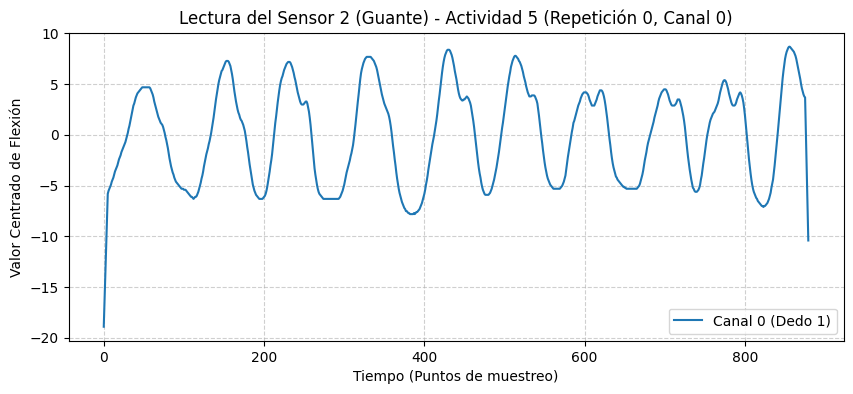

In [3]:
# Cargar la Actividad 5 del Sensor 2
act5_data = np.load(f"{DATA_DIR}/005_2.npy")
print("Forma de Actividad 5 (Sensor 2):", act5_data.shape)

# Seleccionar repetición 0 y canal 0
rep_idx = 0
chan_idx = 0
signal = act5_data[rep_idx, :, chan_idx]

# Graficar en el tiempo
plt.figure(figsize=(10, 4))
plt.plot(signal, color="#1f77b4", linewidth=1.5, label="Canal 0 (Dedo 1)")
plt.title("Lectura del Sensor 2 (Guante) - Actividad 5 (Repetición 0, Canal 0)")
plt.xlabel("Tiempo (Puntos de muestreo)")
plt.ylabel("Valor Centrado de Flexión")
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend()
plt.show()


## Paso 3: Conteo total de repeticiones por actividad (Balanceo de Clases)
Generaremos una gráfica de barras con el conteo de repeticiones de cada una de las 16 actividades para analizar si el dataset está balanceado.


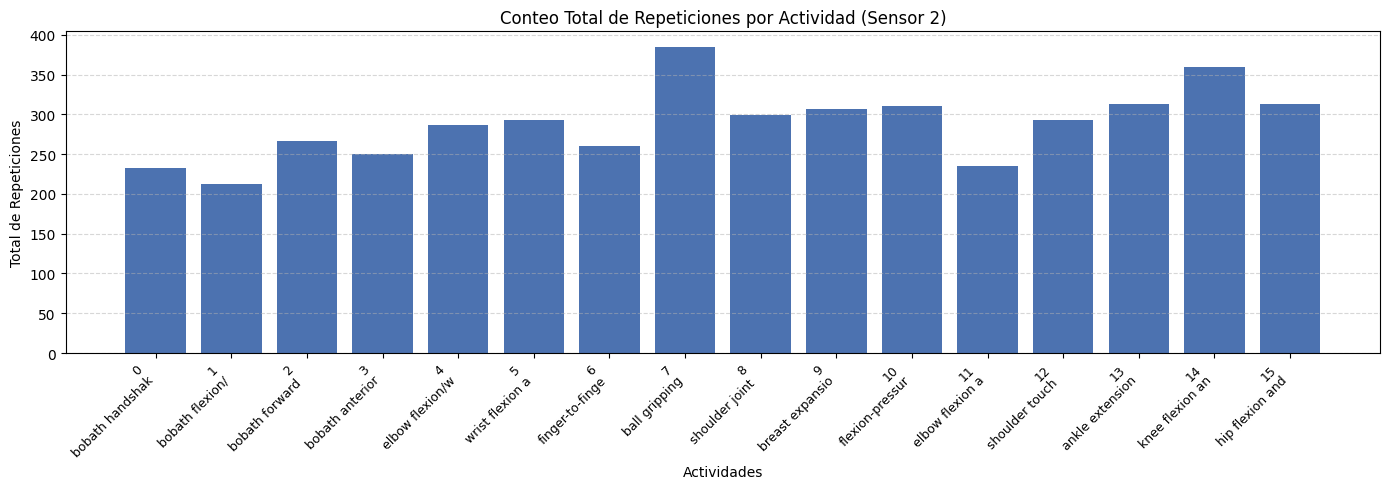

Total de repeticiones en el dataset: 4616
Muestras por clase -> Mínimo: 212, Máximo: 385
Razón Máximo/Mínimo: 1.82


In [4]:
# Obtener los nombres reales de los movimientos para mejor legibilidad
movement_names = {
    0: "bobath handshake",
    1: "bobath flexion/extension",
    2: "bobath forward flexion/extension",
    3: "bobath anterior/posterior rotation",
    4: "elbow flexion/wrist compression",
    5: "wrist flexion and extension",
    6: "finger-to-finger training",
    7: "ball gripping",
    8: "shoulder joint rotation",
    9: "breast expansion",
    10: "flexion-pressure rotation",
    11: "elbow flexion and touch",
    12: "shoulder touch training",
    13: "ankle extension & knee rot.",
    14: "knee flexion and extension",
    15: "hip flexion and extension",
}

counts = {}
for i in range(16):
    f2 = f"{DATA_DIR}/{i:03d}_2.npy"
    if os.path.exists(f2):
        arr = np.load(f2)
        counts[i] = arr.shape[0]
    else:
        counts[i] = 0

plt.figure(figsize=(14, 5))
colors = ["#4C72B0" if c > 0 else "#C44E52" for c in counts.values()]
plt.bar([f"{i}\n{movement_names[i][:15]}" for i in counts.keys()], counts.values(), color=colors)
plt.ylabel("Total de Repeticiones")
plt.xlabel("Actividades")
plt.title("Conteo Total de Repeticiones por Actividad (Sensor 2)")
plt.xticks(rotation=45, ha="right", fontsize=9)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

# Imprimir estadísticas de distribución
total_reps = sum(counts.values())
min_val = min(counts.values())
max_val = max(counts.values())
print(f"Total de repeticiones en el dataset: {total_reps}")
print(f"Muestras por clase -> Mínimo: {min_val}, Máximo: {max_val}")
print(f"Razón Máximo/Mínimo: {max_val / min_val:.2f}")


### ¿Se ven balanceados los conteos?
* **Análisis:** El número de repeticiones por actividad oscila entre **212** (Actividad 1) y **385** (Actividad 7).
* **Conclusión:** La razón entre la clase mayoritaria y la minoritaria es de aproximadamente **1.82**. En el contexto de aprendizaje automático y ciencia de datos clínicos, esta distribución se considera **razonablemente balanceada**. No hay un desbalance extremo que requiera técnicas agresivas de remuestreo (como tener una clase con 10 muestras y otra con 10,000), pero sí es un factor a considerar (por ejemplo, usando estratificación al dividir los conjuntos de datos y métricas como F1-Score).


## Paso 4: Media y Mediana por Actividad
Elegimos el **Canal 0 del Sensor 2**. Para cada actividad, concatenaremos todas sus repeticiones en un solo arreglo plano y calcularemos su media y mediana generales.


In [5]:
stats_list = []
selected_channel = 0

for i in range(16):
    f2 = f"{DATA_DIR}/{i:03d}_2.npy"
    if os.path.exists(f2):
        arr = np.load(f2) # (d, 880, 6)
        # Concatenar todas las repeticiones y puntos temporales para el canal seleccionado
        flat_values = arr[:, :, selected_channel].flatten()
        mean_val = np.mean(flat_values)
        median_val = np.median(flat_values)
        stats_list.append({
            "Actividad": f"Actividad {i:02d} ({movement_names[i]})",
            "Media (Mean)": mean_val,
            "Mediana (Median)": median_val
        })

df_stats = pd.DataFrame(stats_list)
df_stats


,Actividad,Media (Mean),Mediana (Median)
0,Actividad 00 (bobath handshake),1.559185e-15,0.065341
1,Actividad 01 (bobath flexion/extension),9.603905e-16,0.185682
2,Actividad 02 (bobath forward flexion/extension),1.074161e-15,3.167045
3,Actividad 03 (bobath anterior/posterior rotation),9.685343e-16,-0.020227
4,Actividad 04 (elbow flexion/wrist compression),4.141269e-17,0.772273
5,Actividad 05 (wrist flexion and extension),1.137574e-16,0.000000
6,Actividad 06 (finger-to-finger training),-6.956362e-18,0.783409
7,Actividad 07 (ball gripping),-1.740704e-17,0.201136
8,Actividad 08 (shoulder joint rotation),-6.929088e-16,0.085227
9,Actividad 09 (breast expansion),-1.110946e-16,0.147727


### Nota Importante sobre la Media (Cero):
Si observas los valores de la media para todas las actividades, notarás que son prácticamente **0** (del orden de $10^{-15}$). Esto se debe a que las señales en los archivos procesados ya han sido **centradas con respecto a su media** en cada una de las repeticiones individuales (normalización restando la media del canal para cada trial). Como cada ensayo individual tiene media exactamente 0, cualquier concatenación de los mismos resultará en una media de 0. Sin embargo, la mediana sí varía, dándonos información sobre la asimetría de la distribución del canal en cada actividad.


## Paso 5: Comparación de Histogramas de dos Actividades
Elegiremos dos actividades diferentes para comparar la distribución de sus valores (concatenando todas sus repeticiones) en el canal seleccionado (Canal 0):
* **Actividad 5:** *Wrist flexion and extension* (Movimiento enfocado en muñeca).
* **Actividad 7:** *Ball gripping* (Movimiento enfocado en agarre de pelota/dedos).

Graficaremos ambos histogramas juntos y agregaremos líneas verticales para sus respectivas medias.


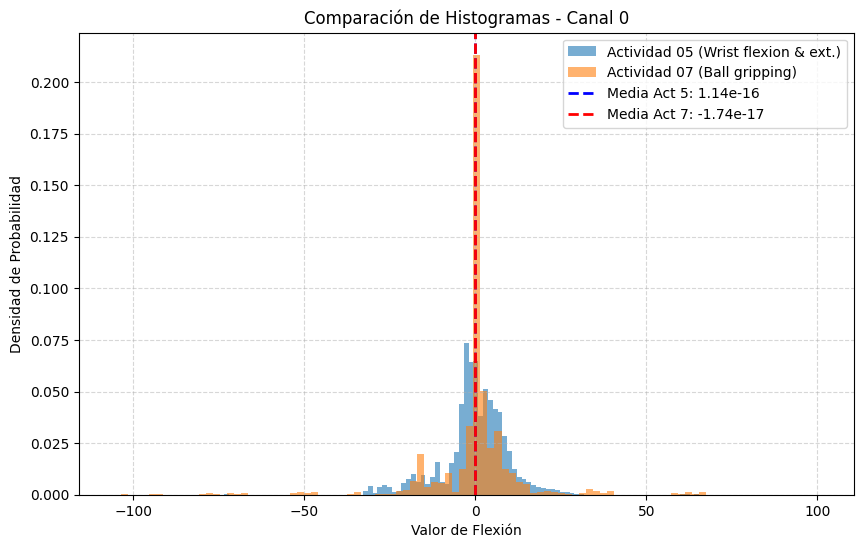

In [6]:
# Cargar datos de ambas actividades
act5_vals = np.load(f"{DATA_DIR}/005_2.npy")[:, :, selected_channel].flatten()
act7_vals = np.load(f"{DATA_DIR}/007_2.npy")[:, :, selected_channel].flatten()

plt.figure(figsize=(10, 6))

# Histograma Actividad 5
plt.hist(act5_vals, bins=100, alpha=0.6, color="#1f77b4", label="Actividad 05 (Wrist flexion & ext.)", density=True)
# Histograma Actividad 7
plt.hist(act7_vals, bins=100, alpha=0.6, color="#ff7f0e", label="Actividad 07 (Ball gripping)", density=True)

# Líneas de la media
plt.axvline(np.mean(act5_vals), color="blue", linestyle="dashed", linewidth=2, label=f"Media Act 5: {np.mean(act5_vals):.2e}")
plt.axvline(np.mean(act7_vals), color="red", linestyle="dashed", linewidth=2, label=f"Media Act 7: {np.mean(act7_vals):.2e}")

plt.title("Comparación de Histogramas - Canal 0")
plt.xlabel("Valor de Flexión")
plt.ylabel("Densidad de Probabilidad")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()


## Paso 6: Explorar diferentes canales y actividades
Probaremos con otros canales y combinaciones de actividades para analizar qué tanto se traslapan sus distribuciones.
* **Caso B:** Canal 1 (Flexión dedo 2) comparando **Actividad 0** (*Bobath handshake*) vs **Actividad 11** (*Elbow joint flexion & touch*).


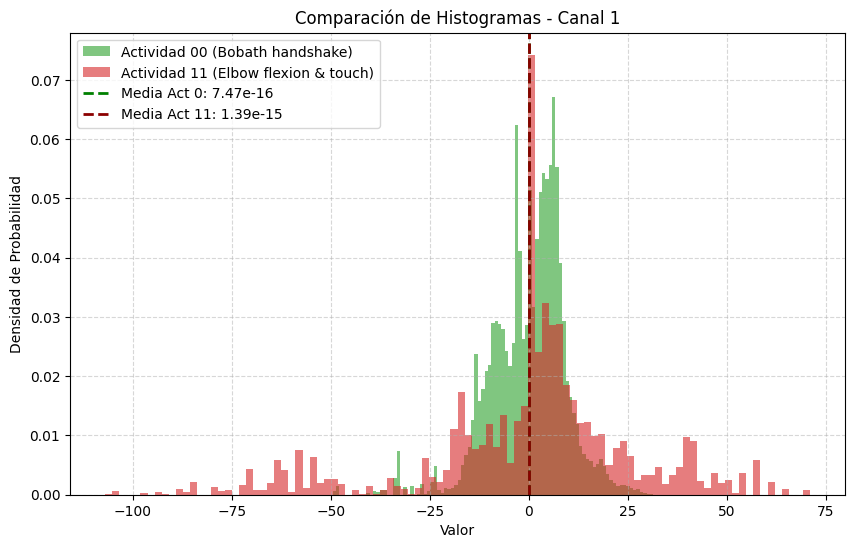

In [7]:
# Seleccionamos Canal 1
selected_channel_2 = 1
act0_vals = np.load(f"{DATA_DIR}/000_2.npy")[:, :, selected_channel_2].flatten()
act11_vals = np.load(f"{DATA_DIR}/011_2.npy")[:, :, selected_channel_2].flatten()

plt.figure(figsize=(10, 6))

plt.hist(act0_vals, bins=100, alpha=0.6, color="#2ca02c", label="Actividad 00 (Bobath handshake)", density=True)
plt.hist(act11_vals, bins=100, alpha=0.6, color="#d62728", label="Actividad 11 (Elbow flexion & touch)", density=True)

plt.axvline(np.mean(act0_vals), color="green", linestyle="dashed", linewidth=2, label=f"Media Act 0: {np.mean(act0_vals):.2e}")
plt.axvline(np.mean(act11_vals), color="darkred", linestyle="dashed", linewidth=2, label=f"Media Act 11: {np.mean(act11_vals):.2e}")

plt.title("Comparación de Histogramas - Canal 1")
plt.xlabel("Valor")
plt.ylabel("Densidad de Probabilidad")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()


## Conclusiones sobre la diferenciación de actividades mediante histogramas
Tras probar con diferentes canales y actividades, podemos concluir lo siguiente:

1. **Traslape Significativo:** La gran mayoría de los histogramas tienen su pico más alto alrededor del 0, ya que los datos están centrados en la media y una buena parte de la señal corresponde a estados en reposo o transiciones suaves.
2. **Diferencias en la dispersión (varianza) y forma:** 
   * Aunque sus medias son idénticas (cero), **la anchura (desviación estándar) y la forma de las distribuciones varían notablemente** entre actividades. Por ejemplo, en el primer gráfico, la Actividad 7 (*Ball gripping*) tiene una distribución con colas más anchas y picos asimétricos debido a los fuertes agarres que flexionan los dedos, a diferencia de la Actividad 5 (*Wrist flexion & extension*).
   * En el segundo gráfico (Canal 1), la Actividad 11 tiene una distribución mucho más estrecha y concentrada que la Actividad 0, indicando que el dedo 2 apenas se mueve en la flexión del codo, pero participa más en el saludo Bobath.
3. **¿Son útiles los histogramas para diferenciar actividades?**
   * **Parcialmente:** Permiten ver diferencias globales en el rango físico de movimiento y el nivel de activación de los sensores (es decir, qué canal se mueve más en qué ejercicio).
   * **Limitación crítica:** El histograma **descarta toda la información temporal**. Dos movimientos con perfiles dinámicos opuestos (ej. uno que empiece rápido y termine lento, vs uno que empiece lento y termine rápido) podrían tener exactamente el mismo histograma. Para una clasificación robusta en Machine Learning, es fundamental conservar el orden temporal de las señales o extraer características dinámicas (frecuencias, RMS en ventanas móviles, o usar modelos como CNN-1D / LSTM).
